In [1]:
import pandas as pd

data = pd.read_csv('Anexo_Projeto_fifa_world_national_teams_versão_oficial_20241.csv', encoding='ISO-8859-1', sep=';')

print("Nomes das colunas:", data.columns)

data.columns = data.columns.str.strip()



Nomes das colunas: Index(['id', 'name', 'full_name', 'overall_rating', 'value_euro', 'wage_euro',
       'nationality', 'national_team', 'club_team', 'age', 'height_cm',
       'weight_kgs', 'international_reputation(1-5)', 'weak_foot(1-5)',
       'skill_moves(1-5)', 'club_rating', 'Goleiro', 'Zagueiro', 'Meio',
       'Atacante', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'dribbling', 'jumping', 'strength', 'long_shots',
       'aggression', 'GK_reflexes'],
      dtype='object')


In [2]:
## Variáveis de Cada Tipo

#Qualitativa Nominal: nationality
#Qualitativa Ordinal: international_reputation(1-5)
#Quantitativa Discreta: age
#Quantitativa Contínua: height_cm

In [2]:
# Tabela de frequência para 'nationality'
nationality_freq = data['nationality'].value_counts()
print("Frequência de Nacionalidades:")
print(nationality_freq)

# Tabela de frequência para 'position'
position_columns = ['Goleiro', 'Zagueiro', 'Meio', 'Atacante']
position_freq = data[position_columns].sum()
print("Frequência de Posições:")
print(position_freq)

Frequência de Nacionalidades:
nationality
England                23
United States          23
Brazil                 23
Spain                  23
Scotland               23
Netherlands            23
Denmark                23
Germany                23
France                 23
Italy                  22
Norway                 22
Turkey                 21
Republic of Ireland    21
Poland                 21
Greece                 21
Wales                  21
Czech Republic         20
Sweden                 20
Finland                19
Canada                 19
Belgium                19
Cameroon               17
Argentina              17
Austria                16
Switzerland            16
Portugal               15
Uruguay                15
Slovenia               14
Ivory Coast            14
Australia              13
Iceland                13
Russia                 13
Venezuela              13
Colombia               12
Romania                11
Chile                  10
Mexico                

In [3]:
# Medidas de posição e variabilidade para 5 variáveis
summary_stats = data[['age', 'height_cm', 'weight_kgs', 'overall_rating', 'value_euro']].describe()

print(summary_stats)

              age   height_cm  weight_kgs  overall_rating    value_euro
count  718.000000  718.000000  718.000000      718.000000  7.180000e+02
mean    26.565460  177.023677   77.674095       76.461003  1.389769e+07
std      3.589156   14.316340    7.298740        6.018383  1.691751e+07
min     18.000000  152.000000   59.000000       58.000000  2.300000e+05
25%     24.000000  170.000000   73.000000       72.000000  3.325000e+06
50%     26.000000  183.000000   77.000000       76.000000  8.000000e+06
75%     29.000000  188.000000   82.000000       80.000000  1.700000e+07
max     37.000000  203.000000  100.000000       94.000000  1.105000e+08


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

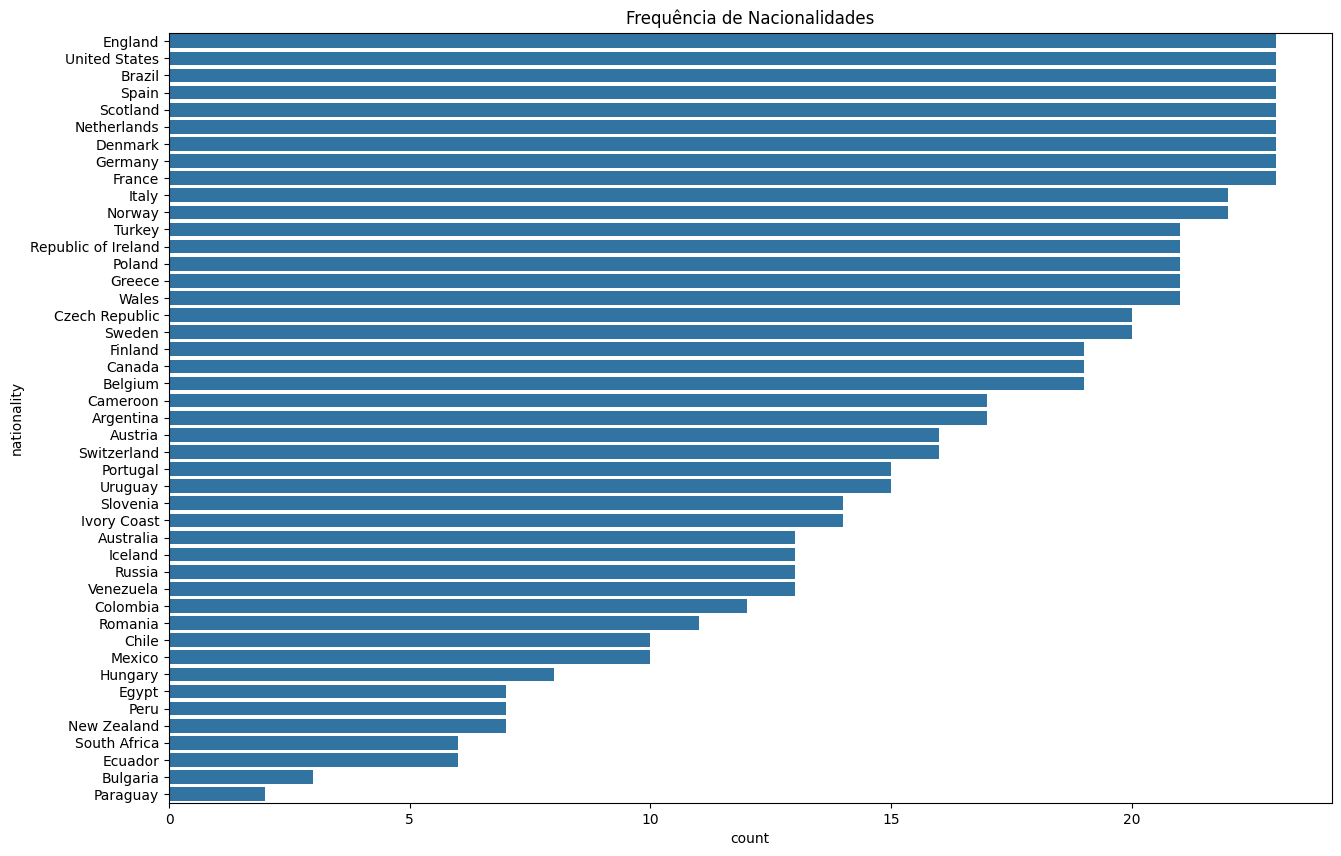

In [5]:
# Gráfico de barras para a frequência de nacionalidades
plt.figure(figsize=(15, 10))
sns.countplot(y='nationality', data=data, order=data['nationality'].value_counts().index)
plt.title('Frequência de Nacionalidades')
plt.show()

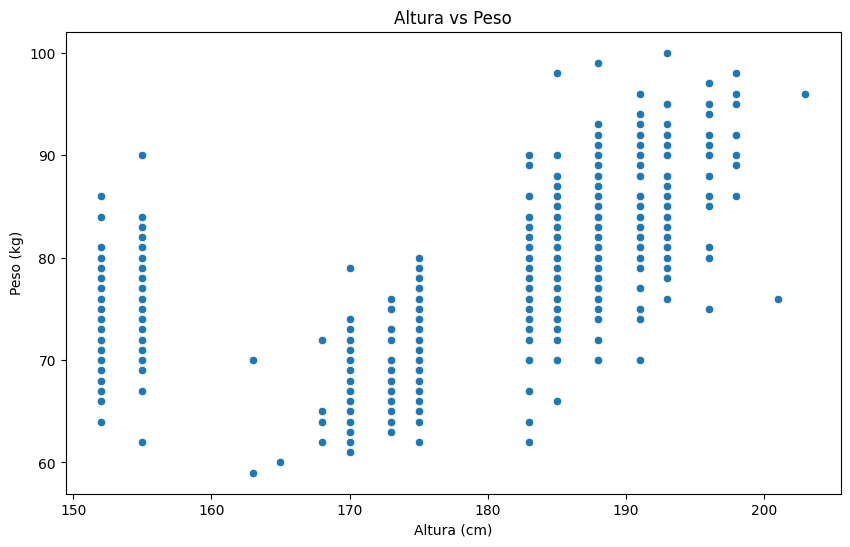

In [6]:
# Gráfico de dispersão para altura vs. peso
plt.figure(figsize=(10, 6))
sns.scatterplot(x='height_cm', y='weight_kgs', data=data)
plt.title('Altura vs Peso')
plt.xlabel('Altura (cm)')
plt.ylabel('Peso (kg)')
plt.show()

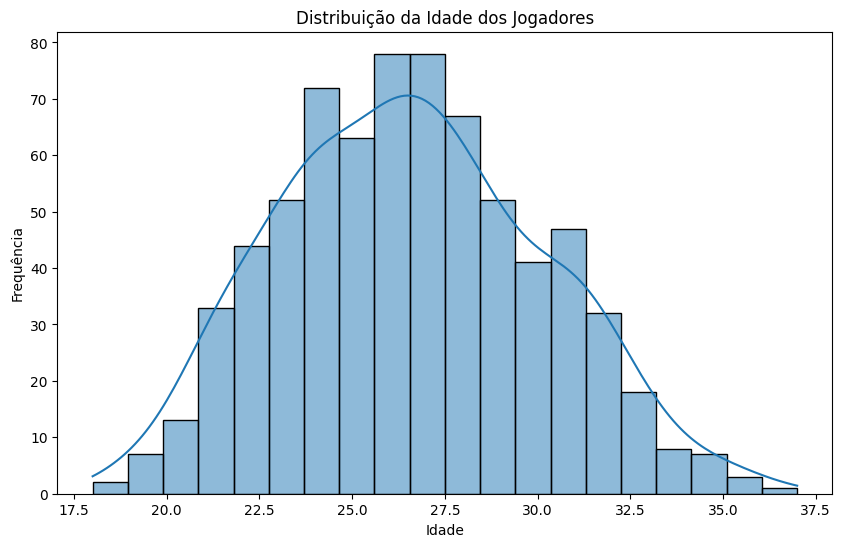

In [7]:
# Histograma para a idade
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], bins=20, kde=True)
plt.title('Distribuição da Idade dos Jogadores')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

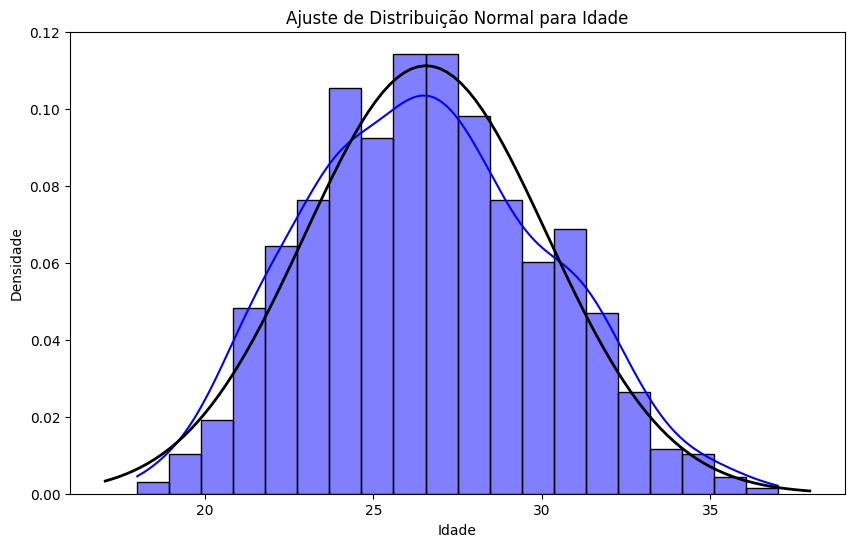

In [9]:
from scipy import stats
import numpy as np

# Ajustando uma distribuição normal
mu, std = stats.norm.fit(data['age'])

# Plotando o histograma e a distribuição ajustada
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], bins=20, kde=True, stat="density", color='blue')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
plt.title('Ajuste de Distribuição Normal para Idade')
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.show()